<a href="https://colab.research.google.com/github/LeonardooAlves/WM9G1-BDAI/blob/main/Week%203/2_NLP_Text_Processing_and_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. What is Natural Language Processing (NLP)?

## 1.1 Definition and Scope

**Natural Language Processing (NLP)** is the sub-field of Artificial Intelligence concerned with enabling computers to understand, interpret, and generate human language. Human language is ambiguous, context-dependent, and rich in nuance — making it fundamentally different from structured data like spreadsheets or database tables. NLP bridges the gap between human communication and machine understanding.

The field sits at the intersection of three disciplines:
- **Linguistics** – understanding grammar, semantics, and the structure of language
- **Computer Science** – algorithms, data structures, and computational systems
- **Statistics / Machine Learning** – learning patterns from data

## 1.2 Why NLP Matters for Business

Text is the most abundant form of unstructured data in the world. Businesses generate enormous quantities of text every day: customer reviews, social media posts, support tickets, contracts, emails, and reports. NLP allows organisations to:

- **Understand customer sentiment** from reviews and social media at scale
- **Automate document processing** (contract analysis, invoice extraction)
- **Power conversational AI** (chatbots, virtual assistants)
- **Extract intelligence** from internal knowledge bases
- **Enable search and recommendation** systems

## 1.3 Key NLP Tasks

| Task | Description | Example Application |
|------|-------------|--------------------|
| **Text Classification** | Assign a category label to a document | Spam detection, topic labelling |
| **Sentiment Analysis** | Determine the emotional tone of text | Product review scoring |
| **Named Entity Recognition (NER)** | Identify names, places, dates in text | Information extraction from news |
| **Topic Modelling** | Discover abstract themes in a corpus | Analysing customer feedback |
| **Machine Translation** | Translate between languages | Google Translate |
| **Text Summarisation** | Generate a shorter version of a document | News summarisation |
| **Question Answering** | Return answers to natural language questions | Search engines, ChatGPT |

## 1.4 The NLP Pipeline

Most NLP tasks follow the same broad pipeline:

```
Raw Text → [Pre-processing] → [Representation / Vectorisation] → [Modelling] → [Insights / Predictions]
```

In this tutorial we walk through each stage using **British Airways customer reviews** as our real-world dataset, finishing with topic modelling to discover what themes passengers most commonly write about.


# 2. Text Pre-processing

## Why Pre-processing?

Raw text data is messy. It contains inconsistent capitalisation, special characters, web addresses, emojis, filler words, and morphological variants of the same word (e.g. *running*, *ran*, *runs*). Feeding raw text directly into a machine learning model would produce poor results because:

1. **Noise obscures signal** – URLs and punctuation add features that carry no semantic meaning
2. **Vocabulary explosion** – treating *Run*, *run*, *running*, and *ran* as four different words wastes model capacity
3. **Sparsity** – most word count matrices are 99%+ zeros; reducing vocabulary density helps models learn

Pre-processing is not universal — the steps you apply depend on your task. Sentiment analysis, for instance, may benefit from keeping exclamation marks (they signal strong emotion), while topic modelling generally does not. Always think critically about each step in the context of your goals.

## Overview of Pre-processing Steps

| Step | Operation | Purpose |
|------|-----------|----------|
| 1 | **Text Cleaning** | Remove noise: URLs, numbers, punctuation, emojis |
| 2 | **Tokenisation** | Split continuous text into discrete tokens (words) |
| 3 | **Stop Word Removal** | Remove very common, semantically empty words |
| 4 | **Stemming / Lemmatisation** | Reduce words to a common base form |
| 5 | **Reconstruction** | Reassemble cleaned tokens into processed text strings |


## Step 1: Text Cleaning

Text cleaning addresses the most obvious sources of noise. We apply each operation sequentially — the order matters because, for example, lowercasing should happen before stop-word removal (which is case-sensitive).

### The operations we apply

| Operation | Reason |
|-----------|--------|
| **Lower casing** | Ensures `Service` and `service` are treated as the same word |
| **Expand contractions** | Converts `I'll` → `I will`, `don't` → `do not`, preventing tokenisation errors |
| **Remove numbers** | Digits rarely carry semantic meaning for text mining tasks |
| **Remove URLs** | Web addresses are not meaningful words |
| **Remove emails/mentions** | Same reason as URLs |
| **Remove emojis** | Symbols outside the ASCII character range cause parsing problems |
| **Remove punctuation** | Punctuation is rarely informative for bag-of-words models |
| **Remove extra spaces** | Normalises whitespace after prior removals leave gaps |

We will demonstrate each step using a sample sentence, then apply the full pipeline to the British Airways review dataset.

> **💡 Encoding note:** If you are working with non-English text (e.g. Chinese, Arabic), you may need to specify a character encoding when reading files. `utf-8` works for most languages; use `latin_1` for Western European languages and `gbk` for Chinese. See the [Python standard encodings list](https://docs.python.org/3/library/codecs.html#standard-encodings).


In [1]:
text = "BDAI github repository https://github.com/LeonardooAlves/WM9G1-BDAI is 🔥🔥 Coding is SUPER fun!!! Hope I'll do it again. By the way James is the best 1234. my email: my_email@gmail.com"
print(text)

BDAI github repository https://github.com/LeonardooAlves/WM9G1-BDAI is 🔥🔥 Coding is SUPER fun!!! Hope I'll do it again. By the way James is the best 1234. my email: my_email@gmail.com


First, let's turn all characters into lower case with the `lower()` method.

In [2]:
# Lower casing
new = text.lower()
new

"bdai github repository https://github.com/leonardooalves/wm9g1-bdai is 🔥🔥 coding is super fun!!! hope i'll do it again. by the way james is the best 1234. my email: my_email@gmail.com"

Observe that now all characters are now lowercase. Notice that `SUPER`, `BDAI`, and `Coding` have been converted to `super`, `bdao`, and `coding`. This ensures that the same word written with different capitalisation is counted as one token later — for example, a sentence-starting `Hope` and a mid-sentence `hope` will now be identical.


Secondly, let's handle the contractions.

In [3]:
# Remove contractions
!pip install contractions

In [4]:
import contractions
new = contractions.fix(new)
new

'bdai github repository https://github.com/leonardooalves/wm9g1-bdai is 🔥🔥 coding is super fun!!! hope i will do it again. by the way james is the best 1234. my email: my_email@gmail.com'

Note that `I'll` has been expanded to `I will`. This is important for tokenisation: without expansion, `I'll` would either become the single nonsense token `ill` or be split incorrectly into `I` and `ll`. The `contractions` library handles hundreds of English contractions automatically.


Thirdly, let's remove numbers.

In [5]:
import re

# remove numbers
new = re.sub(r"\d+", "", new)
new

'bdai github repository https://github.com/leonardooalves/wmg-bdai is 🔥🔥 coding is super fun!!! hope i will do it again. by the way james is the best . my email: my_email@gmail.com'

The number `1234` has been removed.


Finally, remove the URLs.

In [6]:
# Remove urls
new = re.sub(r'http://\S+|https://\S+', '', new)
new

'bdai github repository  is 🔥🔥 coding is super fun!!! hope i will do it again. by the way james is the best . my email: my_email@gmail.com'

The GitHub URL has been completely removed. The regular expression `http://\S+|https://\S+` matches any string that starts with `http://` or `https://` followed by non-whitespace characters, capturing the full URL in one pass.


It is also common to remove emails and emojis. For example:

In [7]:
# Remove email address or @mentions
new = re.sub(r'\S*@\S*\s?', '', new)
new

'bdai github repository  is 🔥🔥 coding is super fun!!! hope i will do it again. by the way james is the best . my email: '

In [8]:
# Remove emoji & emoticons
# First, build a list of commonly used emojis
# emoji/emoticons dictionary here: https://github.com/NeelShah18/emot/blob/master/emot/emo_unicode.py
import re
emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"

                      "]+", re.UNICODE)

new = re.sub(emoj, '', new)
new

'bdai github repository  is  coding is super fun!!! hope i will do it again. by the way james is the best . my email: '

**Email removal:** The pattern `\S*@\S*` matches any string containing an `@` symbol, which covers both email addresses (`my_email@gmail.com`) and social media mentions (`@username`). After removing the email address, only the label `my email:` remains — this trailing text will be cleaned up by punctuation removal.

**Emoji removal:** The fire emojis 🔥🔥 have been stripped using a Unicode range pattern that covers emoticons, symbols, transport icons, and flag characters. This is necessary because emoji codepoints fall outside the standard ASCII range and would appear as garbled text in some NLP pipelines.


In [9]:
# Remove punctuation
import string
import re
new = re.sub('[%s]' % re.escape(string.punctuation), ' ', new)
new

'bdai github repository  is  coding is super fun    hope i will do it again  by the way james is the best   my email  '

Note that now all punctuation marks (the triple exclamation `!!!`, full stops, colons, and the apostrophe in `I'll`) have been replaced with spaces. The `string.punctuation` constant contains all 32 standard ASCII punctuation characters, and `re.escape` ensures none of them are accidentally interpreted as regex special characters.


In [10]:
# Remove extra space
new = re.sub(r'\s{2,}', ' ', new)
new

'bdai github repository is coding is super fun hope i will do it again by the way james is the best my email '

Now you can observe that multiple consecutive spaces (created when URLs, emojis, and punctuation were removed) have been collapsed into single spaces. We now have a clean, normalised string ready for tokenisation.

**Before:** `"BDAO github repository https://github.com/... is 🔥🔥 Coding is SUPER fun!!! Hope I'll do it again. By the way Mark is the best 1234. my email: liping@gmail.com"`

**After:** `'bdao github repository is coding is super fun hope i will do it again by the way james is the best my email'`

The meaningful content words are preserved. Noise has been removed.

---

### Exercise 1 — Text Cleaning

Try modifying the sample text and observe how the cleaning pipeline behaves:

1. **Emoji test:** Replace the fire emojis with a different emoji (e.g. ❤️ or 😂) and re-run. Does the emoji regex still catch it?
2. **Contraction test:** Add the contraction `"shouldn't"` to the text. After running step 1 (lower case) and step 2 (contraction removal), what does it become?
3. **Non-standard URL:** Change the URL to one starting with `ftp://` instead of `https://`. Does the current regex still remove it? How would you fix the regex if it doesn't?
4. **Domain-specific numbers:** Suppose you are analysing flight reviews and want to **keep** flight numbers like `BA243`. Modify the number-removal regex so it only removes standalone numbers (not numbers that are part of longer alphanumeric strings).
> *Hint for Q4:* Use word boundary anchors `\b` in your regex: `re.sub(r'\b\d+\b', '', text)`


## Step 2: Tokenisation

**Tokenisation** is the process of splitting a continuous string of text into a list of discrete units called *tokens*. Most commonly, tokens are words, but they can also be sentences, sub-words, or characters depending on the task.

### Why does tokenisation matter?

All downstream NLP tasks, such as stop-word removal, stemming, and vectorisation, operate on individual tokens rather than raw strings. You cannot remove the word `the` from a string without first knowing where word boundaries are.

### Types of tokenisation

| Type | Description | Example |
|------|-------------|----------|
| **Word tokenisation** | Split on whitespace and punctuation | `"I love NLP"` → `['I','love','NLP']` |
| **Sentence tokenisation** | Split into sentences | `"Good food. Bad service."` → two sentence tokens |
| **Subword tokenisation** | Break rare words into pieces | `"unhappiness"` → `['un','happiness']` |
| **Character tokenisation** | One token per character | `"NLP"` → `['N','L','P']` |

For most text mining tasks (including topic modelling), **word tokenisation** is the standard approach. NLTK's `word_tokenize` function handles edge cases intelligently — for example, it splits `don't` into `do` and `n't` and correctly handles punctuation that is not a word boundary (like the `.` in `U.S.A.`).

### How NLTK's Punkt tokeniser works

NLTK uses a **Punkt tokeniser**, which is a language-model-based approach that has been trained to distinguish sentence-ending periods from abbreviation periods. It is far more robust than simply splitting on spaces.


In [11]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [12]:
# tokenise the words
from nltk.tokenize import word_tokenize
word_token = word_tokenize(new)

word_token

['bdai',
 'github',
 'repository',
 'is',
 'coding',
 'is',
 'super',
 'fun',
 'hope',
 'i',
 'will',
 'do',
 'it',
 'again',
 'by',
 'the',
 'way',
 'james',
 'is',
 'the',
 'best',
 'my',
 'email']

The cleaned string has been split into 23 individual tokens. Notice that each word is now a separate item in a Python list. This is the core data structure that all subsequent pre-processing steps will work with. At this stage:
- Words like `is` and `the` are still present (they will be removed in the stop-word step)
- All tokens are already lowercase (from Step 1)
- No punctuation tokens appear (removed in Step 1)


## Step 3: Stop Word Removal

**Stop words** are high-frequency function words that carry very little semantic content on their own. In English, these include articles (`a`, `the`), prepositions (`in`, `of`, `at`), conjunctions (`and`, `but`), and common pronouns (`I`, `we`, `they`).

### Why remove stop words?

If you count word frequencies across a corpus, stop words will dominate the top of the list — but they reveal nothing meaningful about the *topics* or *content* of the documents. Removing them:

1. **Reduces vocabulary size** – fewer unique tokens means smaller, more efficient models
2. **Improves topic quality** – topic models produce cleaner themes without generic words
3. **Speeds up processing** – less data to vectorise and model

### Caveats and domain-specific stop words

NLTK provides a standard English stop-word list of ~180 words. However, for domain-specific text, you should **extend** this list with words that are very frequent in your corpus but not meaningful for your analysis.

In the British Airways dataset, words like `flight`, `british`, and `airway` appear in virtually every review — they describe the domain, not the *topics* within the domain. Adding them to the stop-word list will help topic models discover more differentiated themes (e.g. customer service problems vs. seat comfort vs. food quality).

> **⚠️ Warning:** Be careful not to over-remove words. For sentiment analysis, words like `not` are stop words in NLTK but are critically important for meaning. Always consider whether a step helps or hurts your specific task.


In [13]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
from nltk.corpus import stopwords
# use English stopwords
stopwords = stopwords.words("english")
stopwords.extend(['app']) #add more stopwords here
token_without_stopwords = [w for w in word_token if not w in stopwords]
token_without_stopwords

['bdai',
 'github',
 'repository',
 'coding',
 'super',
 'fun',
 'hope',
 'way',
 'james',
 'best',
 'email']

The 23 original tokens have been reduced to 11 meaningful content words. Words like `is`, `i`, `by`, `the`, `will`, `it`, `do`, and `again` have been filtered out. What remains are the semantically rich words: `bdai`, `github`, `repository`, `coding`, `super`, `fun`, `hope`, `way`, `james`, `best`, `email`.

Notice that `bdai`, `github`, `repository`, and `email` are domain-specific artefacts from our sample sentence; in a real analysis of airline reviews, you would want to add equivalents of these to your extended stop-word list.


## Step 4: Stemming and Lemmatisation

Even after stop-word removal, the same concept can still appear under multiple surface forms. A customer may write `delayed`, `delay`, `delays`, or `delaying` — all referring to the same event. Normalising these to a common base form reduces vocabulary fragmentation.

### 4.1 Stemming

**Stemming** applies rule-based heuristics to chop off word suffixes. The most widely used algorithm is the **Porter Stemmer** (1980), which applies a cascade of five phases of suffix-stripping rules.

```
running → run     managers → manag     hopeful → hope
```

**Advantages:** Very fast, language-agnostic, deterministic (same input always gives same output).

**Disadvantages:** The output may not be a real word (`manages` → `manag`). This is fine for bag-of-words models (where the token is just a count key) but problematic if you need human-readable output.

### 4.2 Lemmatisation

**Lemmatisation** reduces a word to its dictionary base form (called a *lemma*) by consulting a morphological database. It uses grammatical context (part of speech) to make intelligent decisions:

```
running (verb) → run     better (adj) → good     was (verb) → be
```

**Advantages:** Always produces a valid dictionary word; context-aware (distinguishes `meeting` as noun vs verb).

**Disadvantages:** Slower than stemming; requires POS tagging for best results.

### 4.3 Which should you use?

| Criterion | Stemming | Lemmatisation |
|-----------|----------|---------------|
| Speed | ✅ Fast | ⚠️ Slower |
| Human readability | ❌ Sometimes garbled | ✅ Real words |
| Accuracy | ⚠️ Rule-based errors | ✅ Linguistically correct |
| Best for | Large corpora, speed priority | Smaller corpora, readability priority |

For topic modelling on airline reviews, **lemmatisation is recommended** as it produces readable topic words that can be meaningfully interpreted by business stakeholders.

### 4.4 POS Filtering in Lemmatisation

spaCy's lemmatiser can also filter by **part of speech (POS)**. For topic modelling, we typically keep only:
- **Nouns (NOUN)** – the subjects being discussed (`seat`, `crew`, `delay`)
- **Verbs (VERB)** – actions (`cancel`, `book`, `refund`)
- **Adjectives (ADJ)** – quality descriptors (`comfortable`, `rude`, `excellent`)
- **Adverbs (ADV)** – modifiers (`never`, `always`, `barely`)

Filtering to these four POS categories removes function words that survived the stop-word step while retaining the most semantically rich tokens.


In [15]:
# Stemming
from nltk.stem import PorterStemmer
ps = PorterStemmer()

text = ['managers', 'managing', 'management', 'manage','manages','managed']
stemmed = [ps.stem(w) for w in text]
stemmed

['manag', 'manag', 'manag', 'manag', 'manag', 'manag']

Note that all six variants of the word *manage* have been reduced to `'manag'` — a truncated form that is not a real English word but serves as a consistent index key for all related forms. This illustrates both the strength (perfect normalisation) and the weakness (loss of readability) of stemming.


In [16]:
# Lemmatisation using spaCy
import spacy

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# Process the text with spaCy
doc = nlp(" ".join(text))

# Do lemmatisation
data_lemmatised = [w.lemma_ for w in doc]
# data_lemmatised = [w.lemma_ for w in doc if w.pos_ in ['NOUN', 'ADJ', 'VERB', 'ADV']]
data_lemmatised

['manager', 'manage', 'management', 'manage', 'manage', 'manage']

spaCy produces the real English lemmas: `manager` (the base noun form), `manage` (the verb infinitive), `management` (preserved — the lemma of `management` is itself), and `manage` for all verbal forms. Notice that `managing` and `managed` correctly become `manage`, but `manager` correctly stays `manager` (not `manage`) because it is a noun, not a verb.

This demonstrates the context-sensitivity of lemmatisation: the same surface string could theoretically have different lemmas depending on how it is used.


What if we use NLTK?

In [17]:
# Lemmatisation using nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

n_lemmatised = [lemmatizer.lemmatize(w) for w in text]
v_lemmatised = [lemmatizer.lemmatize(w,'v') for w in n_lemmatised]
r_lemmatised = [lemmatizer.lemmatize(w,'r') for w in v_lemmatised]
a_lemmatised = [lemmatizer.lemmatize(w,'a') for w in r_lemmatised]

a_lemmatised

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


['manager', 'manage', 'management', 'manage', 'manage', 'manage']

NLTK's `WordNetLemmatizer` requires you to specify the part of speech explicitly. Because we do not have POS tags here, the code applies lemmatisation in four passes — noun (`n`), verb (`v`), adverb (`r`), adjective (`a`) — to maximise coverage. The output matches spaCy's in this case. However, NLTK's approach can be less accurate when POS information is ambiguous; spaCy is generally recommended for production pipelines.


In [18]:
# Stemming
from nltk.stem import PorterStemmer
ps = PorterStemmer()

token_stemmed = [ps.stem(w) for w in token_without_stopwords]
token_stemmed

['bdai',
 'github',
 'repositori',
 'code',
 'super',
 'fun',
 'hope',
 'way',
 'jame',
 'best',
 'email']

Applied to the cleaned and stop-word-filtered tokens from our sample sentence, stemming produces `repositori` (from `repository`) — demonstrating how stemming can distort less common words. Content-bearing words like `code`, `fun`, `hope`, `james`, `best`, and `email` are preserved well.


In [19]:
# Lemmatisation using spaCy
import spacy

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# Process the text with spaCy
doc = nlp(" ".join(token_without_stopwords))

# Do lemmatisation keeping only noun, adj, vb, adv
token_lemmatised = [w.lemma_ for w in doc]
token_lemmatised

['bdai',
 'github',
 'repository',
 'cod',
 'super',
 'fun',
 'hope',
 'way',
 'james',
 'good',
 'email']

Lemmatisation Applied to Review Tokens: Lemmatisation correctly keeps `repository` and maps `best` → `good` (the adjective lemma). The output is a clean, human-readable list of meaningful base words that are ready to be joined back into a processed text string.


## Step 5: Reconstructing Processed Text

After tokenisation, stop-word removal, and normalisation, we have a list of tokens. Most vectorisation libraries (CountVectorizer, TfidfVectorizer) and topic modelling tools accept a list of strings (documents), not lists of lists. We therefore need to re-join the token list back into a single space-separated string.

This is as simple as `" ".join(tokens)`. The resulting string is the final pre-processed representation of the document, ready for vectorisation.


In [20]:
# put the tokens back together as text after stemming
new_text = " ".join(token_stemmed)
new_text

'bdai github repositori code super fun hope way jame best email'

In [21]:
# put the tokens back together as text after stemming
new_text = " ".join(token_lemmatised)
new_text

'bdai github repository cod super fun hope way james good email'

Output: Reconstructed Strings

**Stemmed:** `'bdao github repositori code super fun hope way james best email'`  
**Lemmatised:** `'bdao github repository code super fun hope way james good email'`

The difference is visible: `repositori` (stemmed) vs `repository` (lemmatised), and `best` (stemmed) vs `good` (lemmatised). For a topic model that will display topic keywords to business stakeholders, the lemmatised version is far more interpretable.


## Putting It All Together: Batch Pre-processing Pipeline

The steps above were demonstrated one by one on a single sentence. In practice, you will have hundreds or thousands of documents that all need to pass through the same pipeline. The following cells apply the complete pre-processing workflow to the British Airways review dataset.

The pipeline is structured in two stages:

1. **Text Cleaning** (`df[target_column]` operations) – vectorised operations using pandas `.str` methods and `.apply(lambda ...)` for speed
2. **Text Transformation** (tokenisation, stop-word removal, lemmatisation) – applied row-by-row using NLTK and spaCy

We define `target_column = 'reviews'` so that the same pipeline can be repointed to any column in the dataset simply by changing this variable.


In [22]:
# Let's import data first
# Run the code and upload the csv file from your laptop
from google.colab import files
uploaded = files.upload()

Start importing the data

In [23]:
import pandas as pd

data = 'british_airways_reviews.csv' # change the csv file name to your file name that you uploaded
df = pd.read_csv(data)
df.head()

,Unnamed: 0,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others
0,0,“Worst service ever”,Worst service ever. Lost baggage because of d...,23rd January 2024,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconom...,n
1,1,"""unprofessional attitude of the pilots""",BA 246 21JAN 2023 Did not appreciate the unp...,21st January 2024,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat ...,n
2,2,“Next time it will be Jet2”,Not a great experience. I could not check in ...,18th January 2024,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\...,n
3,3,“become the Ryanair of long-haul travel”,I was excited to fly BA as I'd not travelled ...,18th January 2024,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEcon...,n
4,4,“They never help us”,I just want to warn everyone of the worst cu...,17th January 2024,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusi...,n


Choose the column to analyse:

In [24]:
target_column = 'reviews'

In [25]:
# Text cleaning
# Import only if you have not yet done so.
#!pip install contractions

Execute the cleaning steps shown above:

In [26]:
import re
import string
import contractions

# drop data with missing values in the target' column
df = df.dropna(subset=[target_column])

# drop duplicate review content
df = df.drop_duplicates(subset=[target_column])

# remove contraction
df[target_column] = df[target_column].map(lambda x: contractions.fix(x))

# convert the relevant column to lowercase
df[target_column] = df[target_column].str.lower()

# Remove non-word characters, so numbers and ___ etc
df[target_column] = df[target_column].str.replace("[^A-Za-z]", " ", regex = True)

# Remove url link
df[target_column] = df[target_column].apply(lambda x: re.sub(r'http://\S+|https://\S+', '', x))

# Remove email address
df[target_column] = df[target_column].map(lambda x: re.sub(r'\S*@\S*\s?', '', x))

# Remove emoji
emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"

                      "]+", re.UNICODE)

df[target_column] = df[target_column].map(lambda x: re.sub(emoj, '', x))

# Remove punctuation
df[target_column] = df[target_column].map(lambda x: re.sub('[%s]' % re.escape(string.punctuation), ' ', x))

# Remove overspace
df[target_column] = df[target_column].map(lambda x: re.sub(r'\s{2,}', " ", x))

Step 1: Hence, the cleaning pipeline above has been applied to all 1,300 reviews. The original `reviews` column now contains:
- Lowercase text only
- No URLs, email addresses, or emojis
- No punctuation or numbers
- Consistent single-space separation

This dramatically reduces the vocabulary size compared to raw text, which contained proper nouns, brand names with inconsistent capitalisation, and typographical noise.


In [27]:
# Text transformation
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import spacy

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [28]:
# Text transformation

# create a list of the contents from the target column
words = df[target_column].tolist()

# tokenise the words
word_tokens = []
for content in words:
    word_tokens.append(word_tokenize(content))

# remove stop words
stop_words = stopwords.words('english')
stop_words.extend(['flight','british','airway']) #add more stopwords here
tokens_without_stopwords = [] # create a new list with stop words removed
for review in word_tokens:
    tokens_without_stopwords.append([w for w in review if not w in stop_words])


# lemmatisation
nlp = spacy.load("en_core_web_sm") # Load the spaCy model

data_lemmatised = []
for review in tokens_without_stopwords:
    doc = nlp(" ".join(review)) # Process the text with spaCy
    data_lemmatised.append([w.lemma_ for w in doc if w.pos_ in ['NOUN', 'ADJ', 'VERB', 'ADV']]) # keeping only noun, adj, vb, adv

rejoin = []
for content in data_lemmatised:
    x = " ".join(content) # join the text back together
    rejoin.append(x)

# add the reformed text to the data frame
df['cleaned_review'] = rejoin

SStep 2: The above pipeline completeed the Tokenisation, Stop Words, and Lemmatisation

The transformation pipeline has processed all reviews through:
1. **Tokenisation** – each review split into a list of word tokens
2. **Stop-word removal** – NLTK English stop words plus domain-specific words (`flight`, `british`, `airway`) removed
3. **Lemmatisation** – spaCy lemmatises and filters to NOUN, VERB, ADJ, ADV only
4. **Reconstruction** – tokens joined back into a single string stored in `df['cleaned_review']`

The `cleaned_review` column is the final input to the vectorisation and topic modelling stages.


In [29]:
df.head()

,Unnamed: 0,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others,cleaned_review
0,0,“Worst service ever”,worst service ever lost baggage because of de...,23rd January 2024,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconom...,n,bad service ever lose baggage delay miss conne...
1,1,"""unprofessional attitude of the pilots""",ba jan did not appreciate the unprofessional ...,21st January 2024,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat ...,n,appreciate unprofessional attitude pilot sched...
2,2,“Next time it will be Jet2”,not a great experience i could not check in o...,18th January 2024,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\...,n,great experience check online separate part co...
3,3,“become the Ryanair of long-haul travel”,i was excited to fly ba as i would not travel...,18th January 2024,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEcon...,n,excited fly ba travel long travel many occasio...
4,4,“They never help us”,i just want to warn everyone of the worst cus...,17th January 2024,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusi...,n,want warn bad customer service experience ever...


The `df.head()` shows the first 5 rows. The `cleaned_review` column contains the fully processed text. Compare the original `reviews` column with `cleaned_review`:

- **Original:** `" worst service ever lost baggage because of delay missed connection..."` (long, noisy)
- **Cleaned:** `"bad service ever lose baggage delay miss connection..."` (compact, normalised lemmas)

Notice how lemmatisation has standardised verb forms: `lost` → `lose`, `missed` → `miss`. These cleaned strings are now suitable as input for vectorisation algorithms.

---

### Exercise 2 — Pre-processing Pipeline

1. **Custom stop words:** The current pipeline adds `['flight', 'british', 'airway']` to the stop-word list. Add at least three more domain-specific words that you would expect to be very frequent in airline reviews but not meaningful for topic analysis. Re-run the pipeline and inspect `df['cleaned_review'].head()` — has the output changed?

2. **POS filtering:** The lemmatisation line currently keeps `NOUN`, `ADJ`, `VERB`, `ADV`. Modify it to keep **only nouns and adjectives** and re-run. How do the cleaned reviews change? What information might be lost by excluding verbs?

3. **Column swap:** Change `target_column` to `'title'` (the review title column). Re-run the full pipeline. What differences do you notice in the cleaned output compared to using the full review text?

4. **Inspect a specific review:** Pick a review index where the rating is 10 (positive) and another where it is 1 (negative). Print both the original and cleaned versions. Does the cleaning pipeline preserve the key sentiment-bearing words?


# 3. Text Vectorisation

## Why do we need to vectorise text?

Machine learning algorithms operate on numbers, not strings. **Text vectorisation** converts each document into a numerical vector so that we can apply statistical and machine learning techniques.

## 3.1 Bag of Words (BoW) — CountVectorizer

The simplest vectorisation approach treats a document as an unordered *bag* of its words. We:

1. Build a **vocabulary** of all unique words across the corpus
2. Represent each document as a vector of **word counts** over that vocabulary

**Example:**

| Doc | seat | food | delay | service |
|-----|------|------|-------|---------|
| Doc 1: *"bad seat bad service"* | 1 | 0 | 0 | 1 |
| Doc 2: *"food was delay but seat ok"* | 1 | 1 | 1 | 0 |

This is called a **Document-Term Matrix (DTM)**. Each row is a document; each column is a word; each cell is the count of that word in that document.

**Limitation:** BoW ignores word order and treats all words as equally important. Very frequent words dominate the feature space even if they are not particularly informative.

## 3.2 TF-IDF — TfidfVectorizer

**Term Frequency–Inverse Document Frequency (TF-IDF)** addresses the limitation of BoW by downweighting words that appear in many documents. It rewards words that are frequent within a document but rare across the corpus — i.e. words that are *distinctive* to that document.

The formula is:

$$\text{TF-IDF}(t,d) = \underbrace{\frac{\text{count of } t \text{ in } d}{\text{total words in } d}}_{\text{Term Frequency (TF)}} \times \underbrace{\log\left(\frac{N}{\text{num documents containing } t}\right)}_{\text{Inverse Document Frequency (IDF)}}$$

Where:
- **TF** rewards words used frequently in the document
- **IDF** penalises words that appear across almost all documents (they are not distinctive)
- Words appearing in every document get IDF ≈ 0 and are effectively removed

**Example:** The word `good` might appear frequently in a positive review (high TF) but also across most reviews (low IDF) — resulting in a modest TF-IDF score. The word `turbulence`, however, might be rare across all reviews (high IDF) and concentrated in a few specific ones (high TF) — resulting in a high TF-IDF score that marks it as a distinctive feature of those documents.

## 3.3 Comparison

| Method | What it captures | Best for |
|--------|-----------------|----------|
| **CountVectorizer** | Raw frequency | Topic modelling (LDA needs counts) |
| **TfidfVectorizer** | Distinctive importance | Information retrieval, document similarity |


In [30]:
# For creating Term Document Matrix (DTM), CountVectorizer() from scikit-learn
from sklearn.feature_extraction.text import CountVectorizer

# set vectorizer - CountVectorizer for word counts
vectorizer = CountVectorizer()

# create an array of word counts
doc_vec = vectorizer.fit_transform(df.cleaned_review)

# convert this to a dataframe
dtm = pd.DataFrame(doc_vec.toarray(), columns=vectorizer.get_feature_names_out())

# set a threshold to drop infrequent words. here we set overall mean as the threshold. you can change the threshold to control the number of terms
threshold = dtm.mean().mean()

# drop words based on the threshold
dtm = dtm.drop(dtm.mean()[dtm.mean() < threshold].index.values, axis=1) # Here find out the word with average word count lower than the threshold and drop them

# join the two datasets together
# dtm = df.join(dtm, how='left')
dtm.head()

,able,absolutely,accept,acceptable,access,accommodation,account,actually,add,additional,...,word,work,world,worst,worth,write,wrong,year,yet,young
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,0,2,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
dtm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Columns: 865 entries, able to young
dtypes: int64(865)
memory usage: 8.6 MB


The Document-Term Matrix (DTM) now has 1,300 rows (one per review) and 866 columns (one per unique word in the vocabulary after thresholding). Each cell contains the count of how many times that word appears in that review. As expected, most cells are 0 — this is called a **sparse matrix**. The `CountVectorizer` internally uses a sparse format for efficiency; we only convert to a dense DataFrame for inspection.

The vocabulary of 866 words has already been significantly reduced from the raw text by our pre-processing pipeline (lowercasing, stop-word removal, lemmatisation). Without pre-processing, the vocabulary might be 5,000–10,000 words with much higher sparsity.


In [32]:
# create a list of words sorted by counts descending
word_freq = dtm.sum(axis=0)
word_freq_df = pd.DataFrame({'word': word_freq.index, 'count': word_freq.values})
word_freq_df = word_freq_df.sort_values(by='count', ascending=False)
word_freq_df.head(10) # change number in head() to control the top n

,word,count
677,seat,1322
690,service,999
784,time,787
373,hour,724
336,get,721
342,good,647
189,crew,633
315,food,628
312,fly,626
136,check,569


This table above lists the ten most frequently occurring words across all 1,300 reviews. These words represent the dominant themes in the corpus. In airline reviews, words like `service`, `seat`, `staff`, `time`, and `cancel` typically dominate — reflecting the core dimensions passengers care about.

High-frequency words in BoW analysis reveal the *most discussed* topics but not necessarily the most *distinctive* ones. For that, see the TF-IDF analysis below.


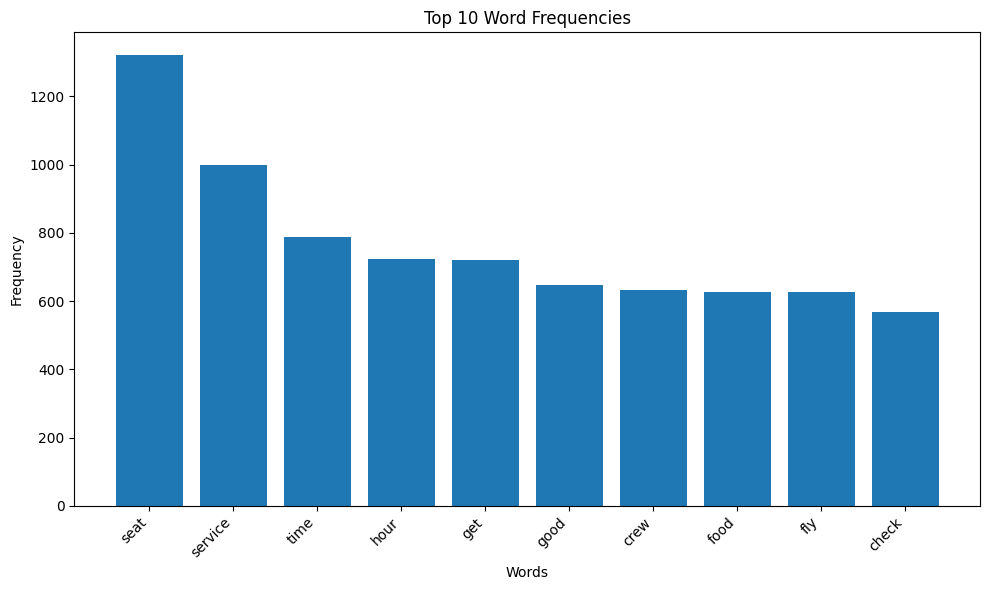

In [33]:
# create a bar showing top 10 words sorted by counts descending

import matplotlib.pyplot as plt

word_freq = dtm.sum(axis=0)
word_freq_df = pd.DataFrame({'word': word_freq.index, 'count': word_freq.values}).sort_values(by='count', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(word_freq_df['word'].head(10), word_freq_df['count'].head(10)) # change number in head() to control the top n
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Word Frequencies")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


**Reading the chart:** Each bar represents one of the top 10 words; bar height indicates total count across the full corpus.

**What to look for:**

- **Dominant themes:** The tallest bars identify the subjects that passengers discuss most. If `service` and `staff` are the top words, it suggests that customer-facing interactions are the primary subject of BA reviews.
- **Negative vs positive vocabulary:** Without filtering by sentiment, both positive reviews (`excellent service`) and negative reviews (`terrible service`) contribute to the `service` count. High frequency of service-related words simply indicates salience, not valence.
- **Steep drop-off:** If the 1st bar is much taller than the 10th, the corpus is dominated by a small number of themes — a common pattern in domain-specific text.

**Limitation:** Frequency alone cannot tell us whether these words are associated with positive or negative reviews, nor how they relate to each other. This is why we proceed to topic modelling.


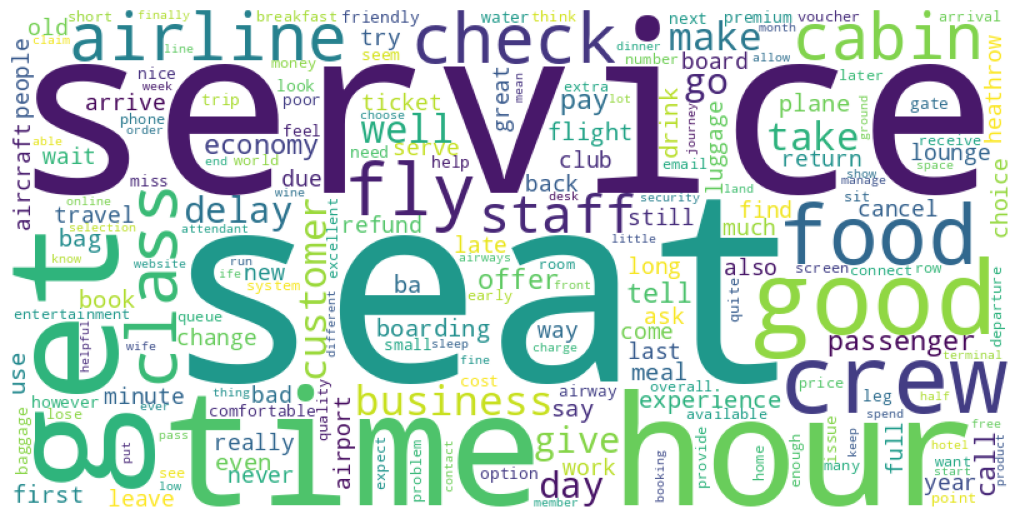

In [34]:
# create a wordcloud with countvectoriser results
from wordcloud import WordCloud
import matplotlib.pyplot as plt

word_freq = dtm.sum(axis=0)  # Sum word counts across all documents

# create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

# display the generated image
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

**Reading the word cloud:** Word size is proportional to frequency. The largest words are the most common across all reviews; smaller words appear less often.

**Insights:**
- The word cloud gives a quick, visually intuitive summary of the corpus vocabulary
- You can immediately spot whether certain themes (e.g. `service`, `cabin`, `seat`, `crew`) are prominent
- Clusters of related words (e.g. words about food: `meal`, `food`, `drink`) may suggest natural topic groups

**Comparing to the bar chart:** The word cloud and bar chart convey the same frequency information but serve different audiences. Bar charts are better for precise comparisons between words; word clouds are better for a first-glance overview or for presentations to non-technical stakeholders.

**Limitation:** Like all frequency-based visualisations, the word cloud is dominated by globally common words. The TF-IDF word cloud below will highlight more distinctive terms.


In [35]:
# We can use the same process to creat document term matrix by considering the importance of the words
# Here we will use TfidfVectorizer() from scikit-learn to convert a collection of raw documents to a matrix of TF-IDF features.
from sklearn.feature_extraction.text import TfidfVectorizer

# set vectorizer - CountVectorizer for word counts
tfidfvectorizer = TfidfVectorizer()

# create an array of word counts
vec = tfidfvectorizer.fit_transform(df.cleaned_review)

# convert this to a dataframe
tfidf = pd.DataFrame(vec.toarray(), columns=tfidfvectorizer.get_feature_names_out())

# set a threshold to drop infrequent words. here we set overall mean as the threshold. you can change the threshold to control the number of terms
threshold = tfidf.mean().mean()

# drop words based on the threshold
tfidf = tfidf.drop(tfidf.mean()[tfidf.mean() < threshold].index.values, axis=1) # Here find out the word with average word count lower than the threshold and drop them

# join the two datasets together
# tfidf = df.join(tfidf, how='left')

tfidf.head()

,able,absolute,absolutely,abysmal,accept,acceptable,access,accommodate,accommodation,accord,...,working,world,worst,worth,write,wrong,year,yesterday,yet,young
0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.10598,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
# create a list of words sorted by tfidf score descending
word_tfidf = tfidf.sum(axis=0)
word_tfidf_df = pd.DataFrame({'word': word_tfidf.index, 'tfidf': word_tfidf.values})
word_tfidf_df = word_tfidf_df.sort_values(by='tfidf', ascending=False)
word_tfidf_df.head(10) # change number in head() to control the top n

,word,tfidf
860,seat,62.865160
876,service,47.075735
430,good,41.147643
466,hour,40.418480
1005,time,40.193584
237,crew,37.955826
399,food,37.323185
424,get,36.521605
180,class,36.107824
396,fly,35.688611


Top 10 Words by TF-IDF Score: TF-IDF scores sum the per-document importance scores across all documents. A high aggregate TF-IDF score means a word is consistently *distinctive* within individual documents — it appears a lot in some documents but not uniformly across all of them.

**Compare TF-IDF top words with the BoW top words:** TF-IDF often surfaces more specific, informative terms (e.g. `refund`, `compensation`, `rebook`) that BoW might rank lower because they are less frequent globally but more informative when they do appear.


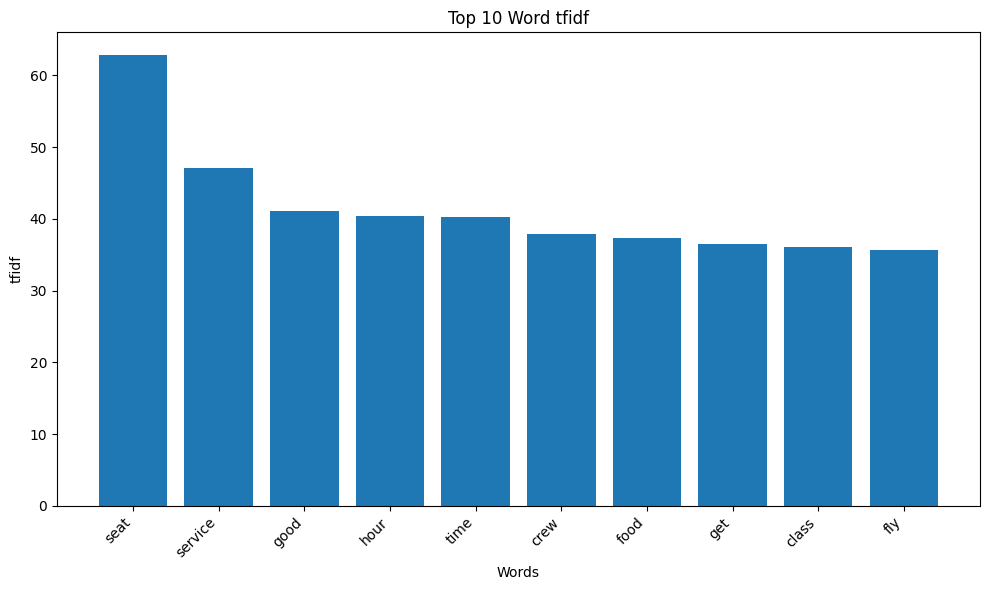

In [37]:
# create a bar showing top 10 words sorted by counts descending

import matplotlib.pyplot as plt

word_tfidf = tfidf.sum(axis=0)
word_tfidf_df = pd.DataFrame({'word': word_tfidf.index, 'tfidf': word_tfidf.values}).sort_values(by='tfidf', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(word_tfidf_df['word'].head(10), word_tfidf_df['tfidf'].head(10)) # change number in head() to control the top n
plt.xlabel("Words")
plt.ylabel("tfidf")
plt.title("Top 10 Word tfidf")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

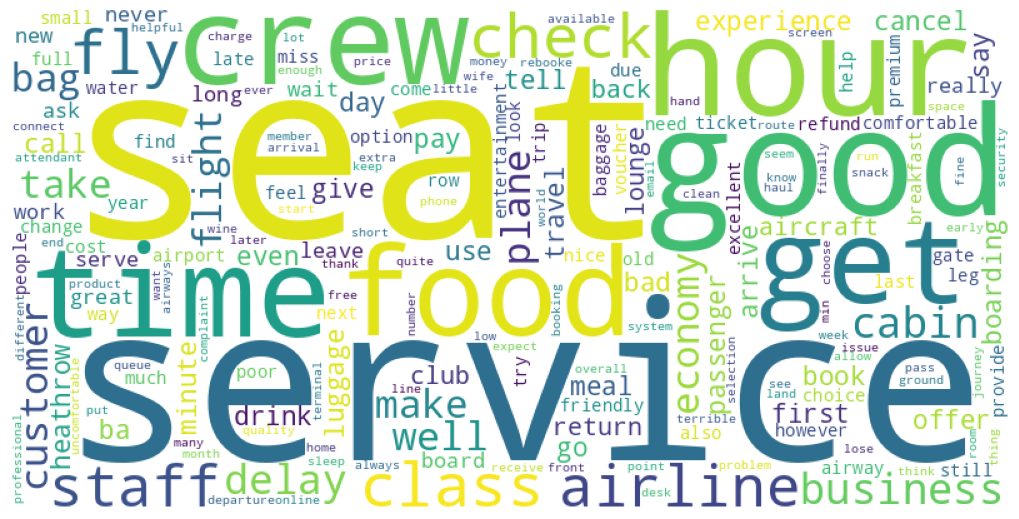

In [38]:
# create a wordcloud with tfidfvectoriser results
from wordcloud import WordCloud
import matplotlib.pyplot as plt

word_tfidf = tfidf.sum(axis=0)  # Sum tfidf across all documents

# create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_tfidf)

# Display the generated image:
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

**Interpreting TF-IDF scores:** Unlike raw counts, TF-IDF scores are not directly interpretable as 'X reviews mention this word'. They reflect a weighted importance that balances frequency (TF) against commonness (IDF).

**Key comparison — BoW vs TF-IDF:**
- Words that appear in the BoW top 10 but not the TF-IDF top 10 are too *common* to be distinctive — they appear in so many reviews that their IDF weight is low
- Words that appear in the TF-IDF top 10 but not the BoW top 10 are *distinctive* — highly relevant when they appear, but not universal

**Business insight:** TF-IDF word clouds are more useful for understanding *what makes certain reviews different* from others. For example, reviews about compensation processes will have high TF-IDF scores for words like `refund`, `claim`, and `voucher`, even if these words are rare overall. This makes TF-IDF particularly valuable for identifying niche but important complaint categories.

---

### Exercise 3 — Text Vectorisation

1. **Top N words:** Change the `head(10)` calls in cells 35 and 39 to `head(25)`. What additional themes emerge in the top 25 words? Are there any words that seem like they should have been removed as stop words?

2. **Vocabulary threshold:** `CountVectorizer` has a `min_df` parameter that filters out words appearing in fewer than `min_df` documents. Add `min_df=5` to the vectoriser and observe how the vocabulary size changes. Does this affect the top words?

3. **Bigrams:** Modify the vectoriser to include bigrams: `CountVectorizer(ngram_range=(1,2))`. What new two-word phrases appear in the top words? How do phrases like `customer service` or `check in` change your understanding of the reviews?

4. **Comparison question:** Create a filtered sub-corpus: `positive_reviews = df[df['user_ratings'] >= 8]['cleaned_review']` and `negative_reviews = df[df['user_ratings'] <= 3]['cleaned_review']`. Fit separate CountVectorizers on each and compare the top 10 words. What differences do you observe?


# 4. Topic Modelling with LDA

## What is Topic Modelling?

**Topic modelling** is an unsupervised machine learning technique that discovers abstract *themes* (topics) latent in a collection of documents. You do not provide labels or categories in advance — the algorithm infers the structure directly from word co-occurrence patterns.

In the context of airline reviews, topic modelling can automatically discover that some reviews are primarily about *in-flight food*, others about *baggage handling*, others about *customer service responsiveness*, and so on — without any manual labelling.

## 4.1 Latent Dirichlet Allocation (LDA)

**LDA** (Blei, Ng & Jordan, 2003) is the classic probabilistic topic model. It makes the following generative assumptions:

1. **Each document is a mixture of topics.** A single review might be 60% about seat comfort, 30% about food, and 10% about check-in.
2. **Each topic is a distribution over words.** The 'seat comfort' topic assigns high probability to words like `seat`, `legroom`, `comfortable`, `recline`.

The model uses **Dirichlet distributions** (a distribution over probability distributions) to model both of these mixtures. The 'Latent' in LDA refers to the fact that topics are hidden variables — we observe only the words, and the algorithm must infer the topics.

### The LDA generative process (simplified)

For each document $d$:
1. Draw a topic distribution $\theta_d$ ~ Dirichlet($\alpha$)
2. For each word position in the document:
   - Draw a topic $z$ ~ Multinomial($\theta_d$)
   - Draw a word $w$ ~ Multinomial($\phi_z$)

Given the observed words, LDA uses **variational inference** or **Gibbs sampling** to estimate the hidden variables $\theta$ (document-topic distributions) and $\phi$ (topic-word distributions).

### Key hyperparameters

| Parameter | Role | Effect of increasing |
|-----------|------|---------------------|
| **k (n_components)** | Number of topics | More fine-grained topics; risk of fragmentation |
| **α (doc-topic prior)** | Expected topic diversity per document | Higher α → documents cover more topics |
| **β (topic-word prior)** | Expected word diversity per topic | Higher β → topics are broader, less distinctive |

Choosing `k` (the number of topics) is the most important decision. There is no single correct answer — start with a number that makes intuitive sense for your domain (e.g. 4–8 for airline reviews) and iterate.

### Why LDA needs CountVectorizer (not TF-IDF)

LDA models raw **word counts** because its probabilistic generative model assumes integer-valued word occurrences. TF-IDF produces non-integer weighted scores that would violate the model's assumptions.


In [39]:
# vectorise the data into word counts

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA

# this limits the vocabulary size to the 1000 most frequent words, potentially improving efficiency.
max_words = 1000 # you can adjust the size based on your data size
vectorizer = CountVectorizer(max_features=max_words)
# vectorizer = CountVectorizer()
vec = vectorizer.fit_transform(df['cleaned_review'])

k = 4 #this is the number of the topic. you can decide the number

lda = LDA(n_components=k, learning_method='online', random_state = 42)
lda.fit(vec)

LatentDirichletAllocation(learning_method='online', n_components=4,
                          random_state=42)

Note that the LDA model has been fitted with `k=4` topics on a vocabulary of up to 1,000 most frequent words. The `online` learning method (online variational Bayes) processes the corpus in mini-batches, which is more memory-efficient than the `batch` method for larger datasets.

After fitting, `lda.components_` is a matrix of shape `(k, vocabulary_size)` = (4, 1000) where each row is a topic and each value represents the model's learned weight for that word in that topic. Higher values mean the word is more characteristic of that topic.


Topic#  1
good,seat,crew,food,service,cabin,time,well,meal,drink,first,class,offer,lounge,experience,serve,club,boarding,staff,comfortable,get,economy,take,friendly,business,great,check,breakfast,hour,really,overall,nice,new,sleep,make,aircraft,quite,choice,use,fly,long,excellent,passenger,entertainment,board,full,world,minute,old,screen

Topic#  2
get,hour,customer,call,tell,day,service,cancel,book,time,delay,go,say,fly,refund,airline,give,airport,make,bag,try,find,arrive,ticket,travel,check,take,pay,phone,never,miss,due,flight,ask,wait,back,email,voucher,change,number,even,help,issue,offer,connect,later,next,receive,ba,return

Topic#  3
check,staff,bag,luggage,passenger,boarding,gate,service,take,hand,crew,time,late,baggage,rude,board,minute,delay,cabin,terminal,arrive,heathrow,drop,water,give,queue,travel,plane,overhead,small,also,make,cost,attendant,carry,pass,go,ask,airline,desk,seem,find,serve,slow,frequent,security,ground,lose,locker,covid

Topic#  4
seat,class,business,airline,

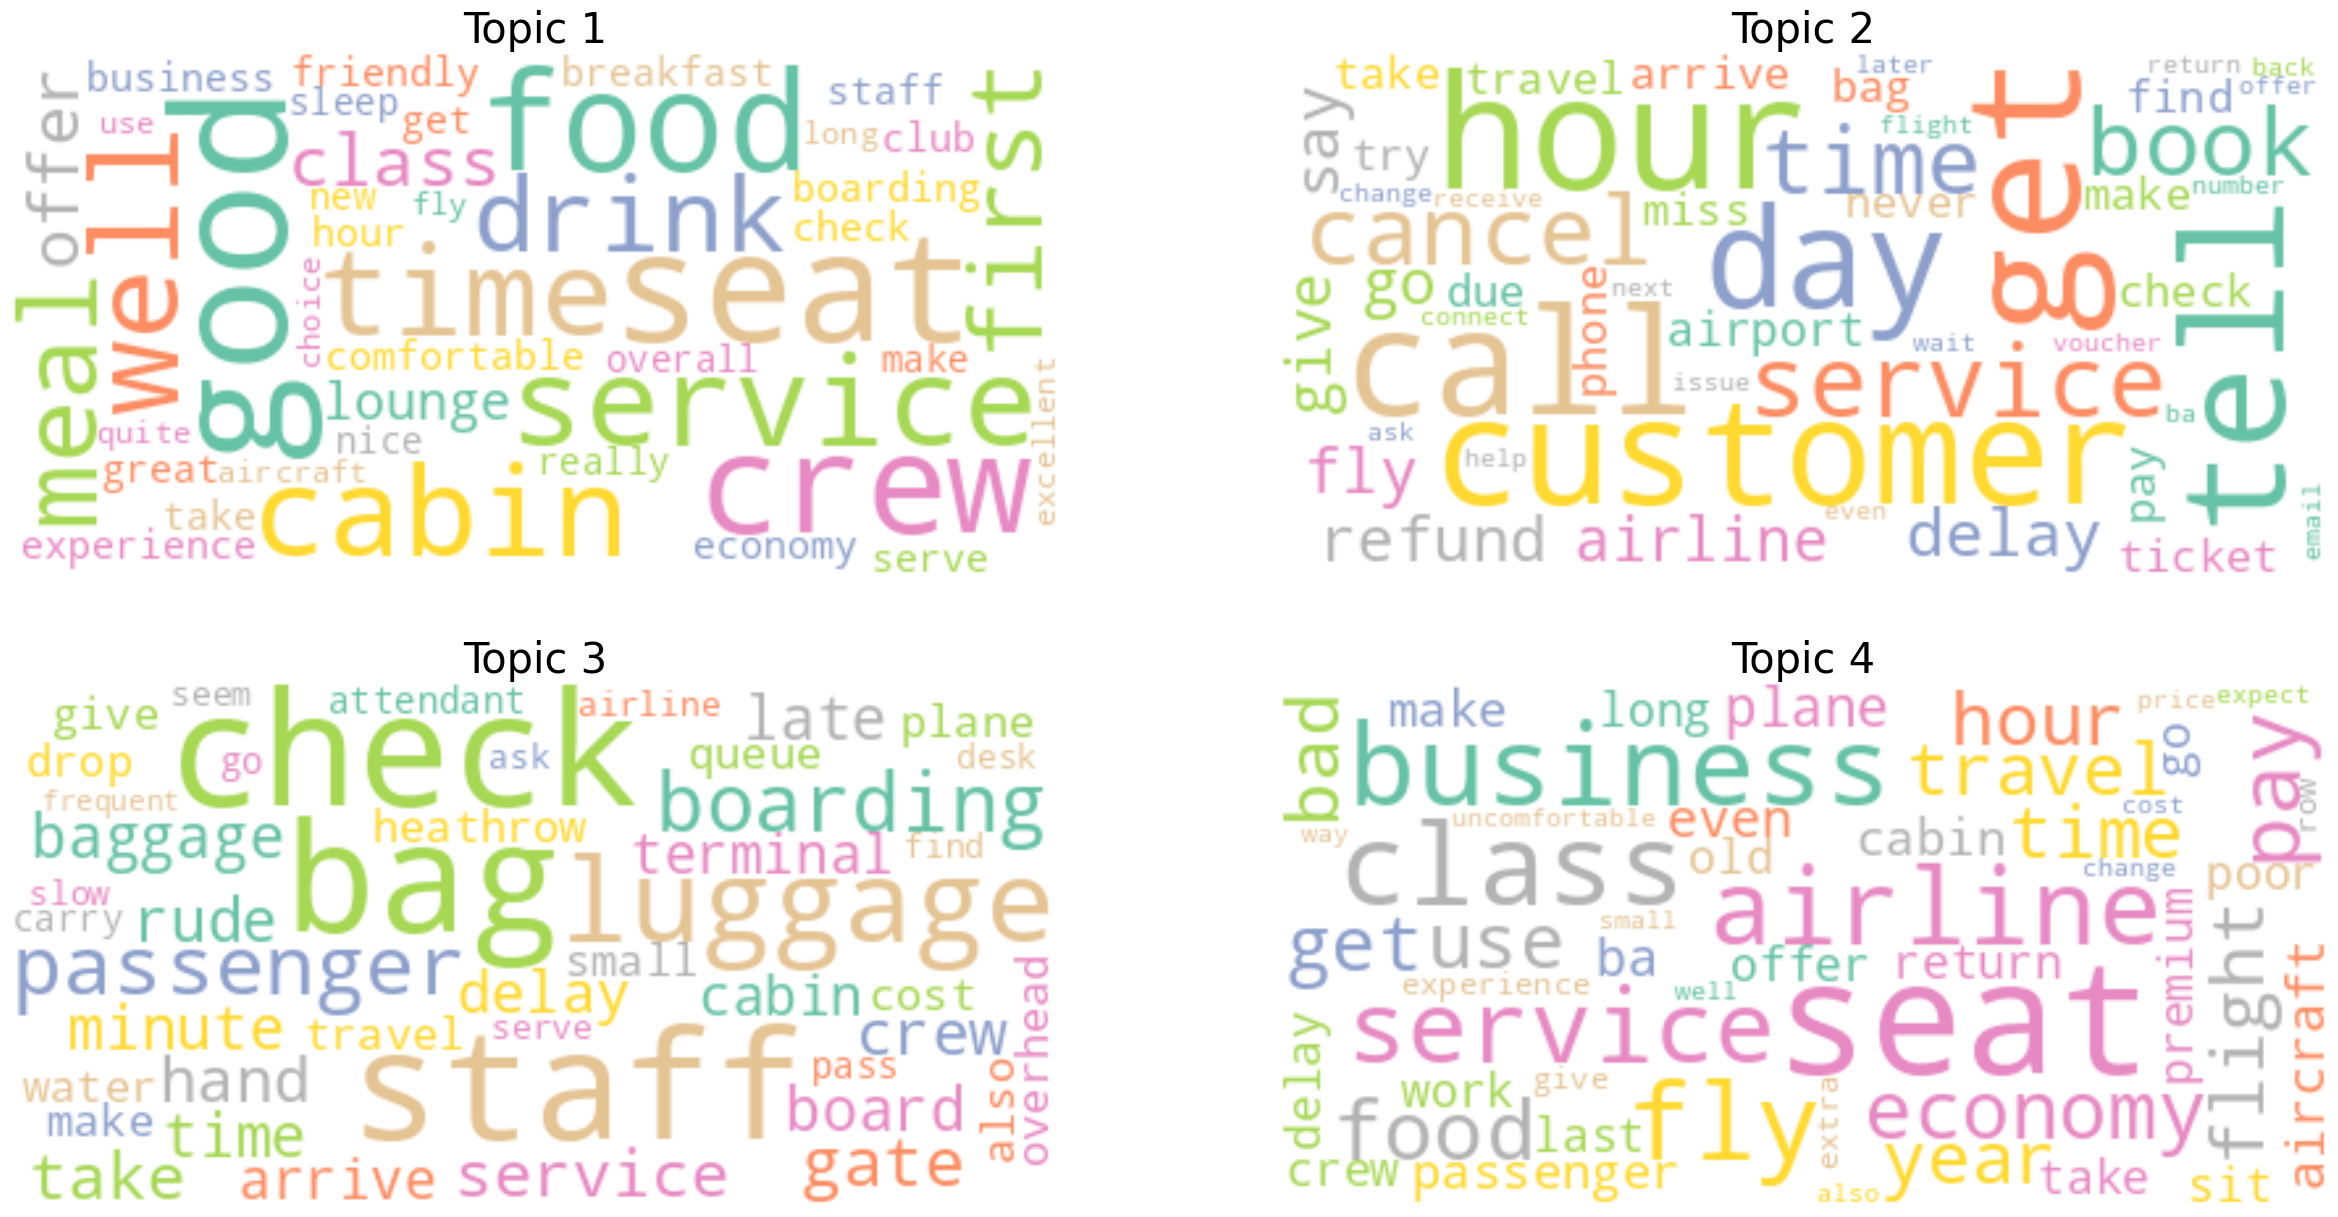

In [40]:
#Matplotlib inline is a backend command in Jupyter Notebooks that enables the rendering of Matplotlib plots directly below
#code cells. This means that when you execute code that generates Matplotlib plots, the plots are displayed inline within
#the notebook, rather than in a separate window or output cel.
%matplotlib inline

import matplotlib.pyplot as plt
import wordcloud

#declaring number of terms we need per topic
terms_count = 50

terms = vectorizer.get_feature_names_out()

wcloud = wordcloud.WordCloud(background_color="White",mask=None, max_words=100,\
                             max_font_size=60,min_font_size=10,prefer_horizontal=0.9,
                             contour_width=3,contour_color='Black',colormap='Set2')

fig, axes = plt.subplots(2, 2, figsize=(30, 15), sharex=True) # adjust your subplots based on how many topics you are generating.
axes = axes.flatten()

for idx,topic in enumerate(lda.components_):
    print('Topic# ',idx+1)
    abs_topic = abs(topic)
    topic_terms = [[terms[i],topic[i]] for i in abs_topic.argsort()[:-terms_count-1:-1]]
    topic_terms_sorted = [[terms[i], topic[i]] for i in abs_topic.argsort()[:-terms_count - 1:-1]]
    topic_words = []
    for i in range(terms_count):
        topic_words.append(topic_terms_sorted[i][0])
    print(','.join( word for word in topic_words))
    print("")
    dict_word_frequency = {}

    for i in range(terms_count):
        dict_word_frequency[topic_terms_sorted[i][0]] = topic_terms_sorted[i][1]

    ax = axes[idx]
    ax.set_title(f'Topic {idx +1}',fontdict={'fontsize': 30})
    wcloud.generate_from_frequencies(dict_word_frequency)
    ax.imshow(wcloud, interpolation='bilinear')
    ax.axis("off")

Each word cloud above represents one discovered topic. Word size reflects the word's weight (importance) within that topic, as learned by the LDA model.

**How to interpret the topics:**

Look at the largest words in each cloud and ask: *'What theme do these words collectively describe?'* Give each topic a short, human-readable label. For British Airways reviews, you might find themes such as:

- **In-flight Experience:** `crew`, `food`, `drink`, `service`, `seat`
- **Customer Service:** `cancel`, `customer`, `refund`, `call`, `delay`
- **Operations:** words like `check`, `cancel`, `luggage`, `staff`, `terminal`
- **Overall Satisfaction:** `bad`, `service`, `airline`, `uncomfortable`, `price`

**Things to observe:**
- **Topic coherence:** Do the words in each cloud tell a consistent story? High coherence means the algorithm has found a real theme
- **Topic overlap:** If the same words appear prominently in multiple topics, you may have too many topics (decrease `k`) or the topics are genuinely related
- **Outlier words:** If a word seems out of place in a topic, inspect some documents assigned to that topic — context often explains the association

> **Important:** LDA topic labels (e.g. 'Topic 1', 'Topic 2') are arbitrary — the algorithm has no knowledge of what the topics mean. Human interpretation is always required to assign meaningful names.


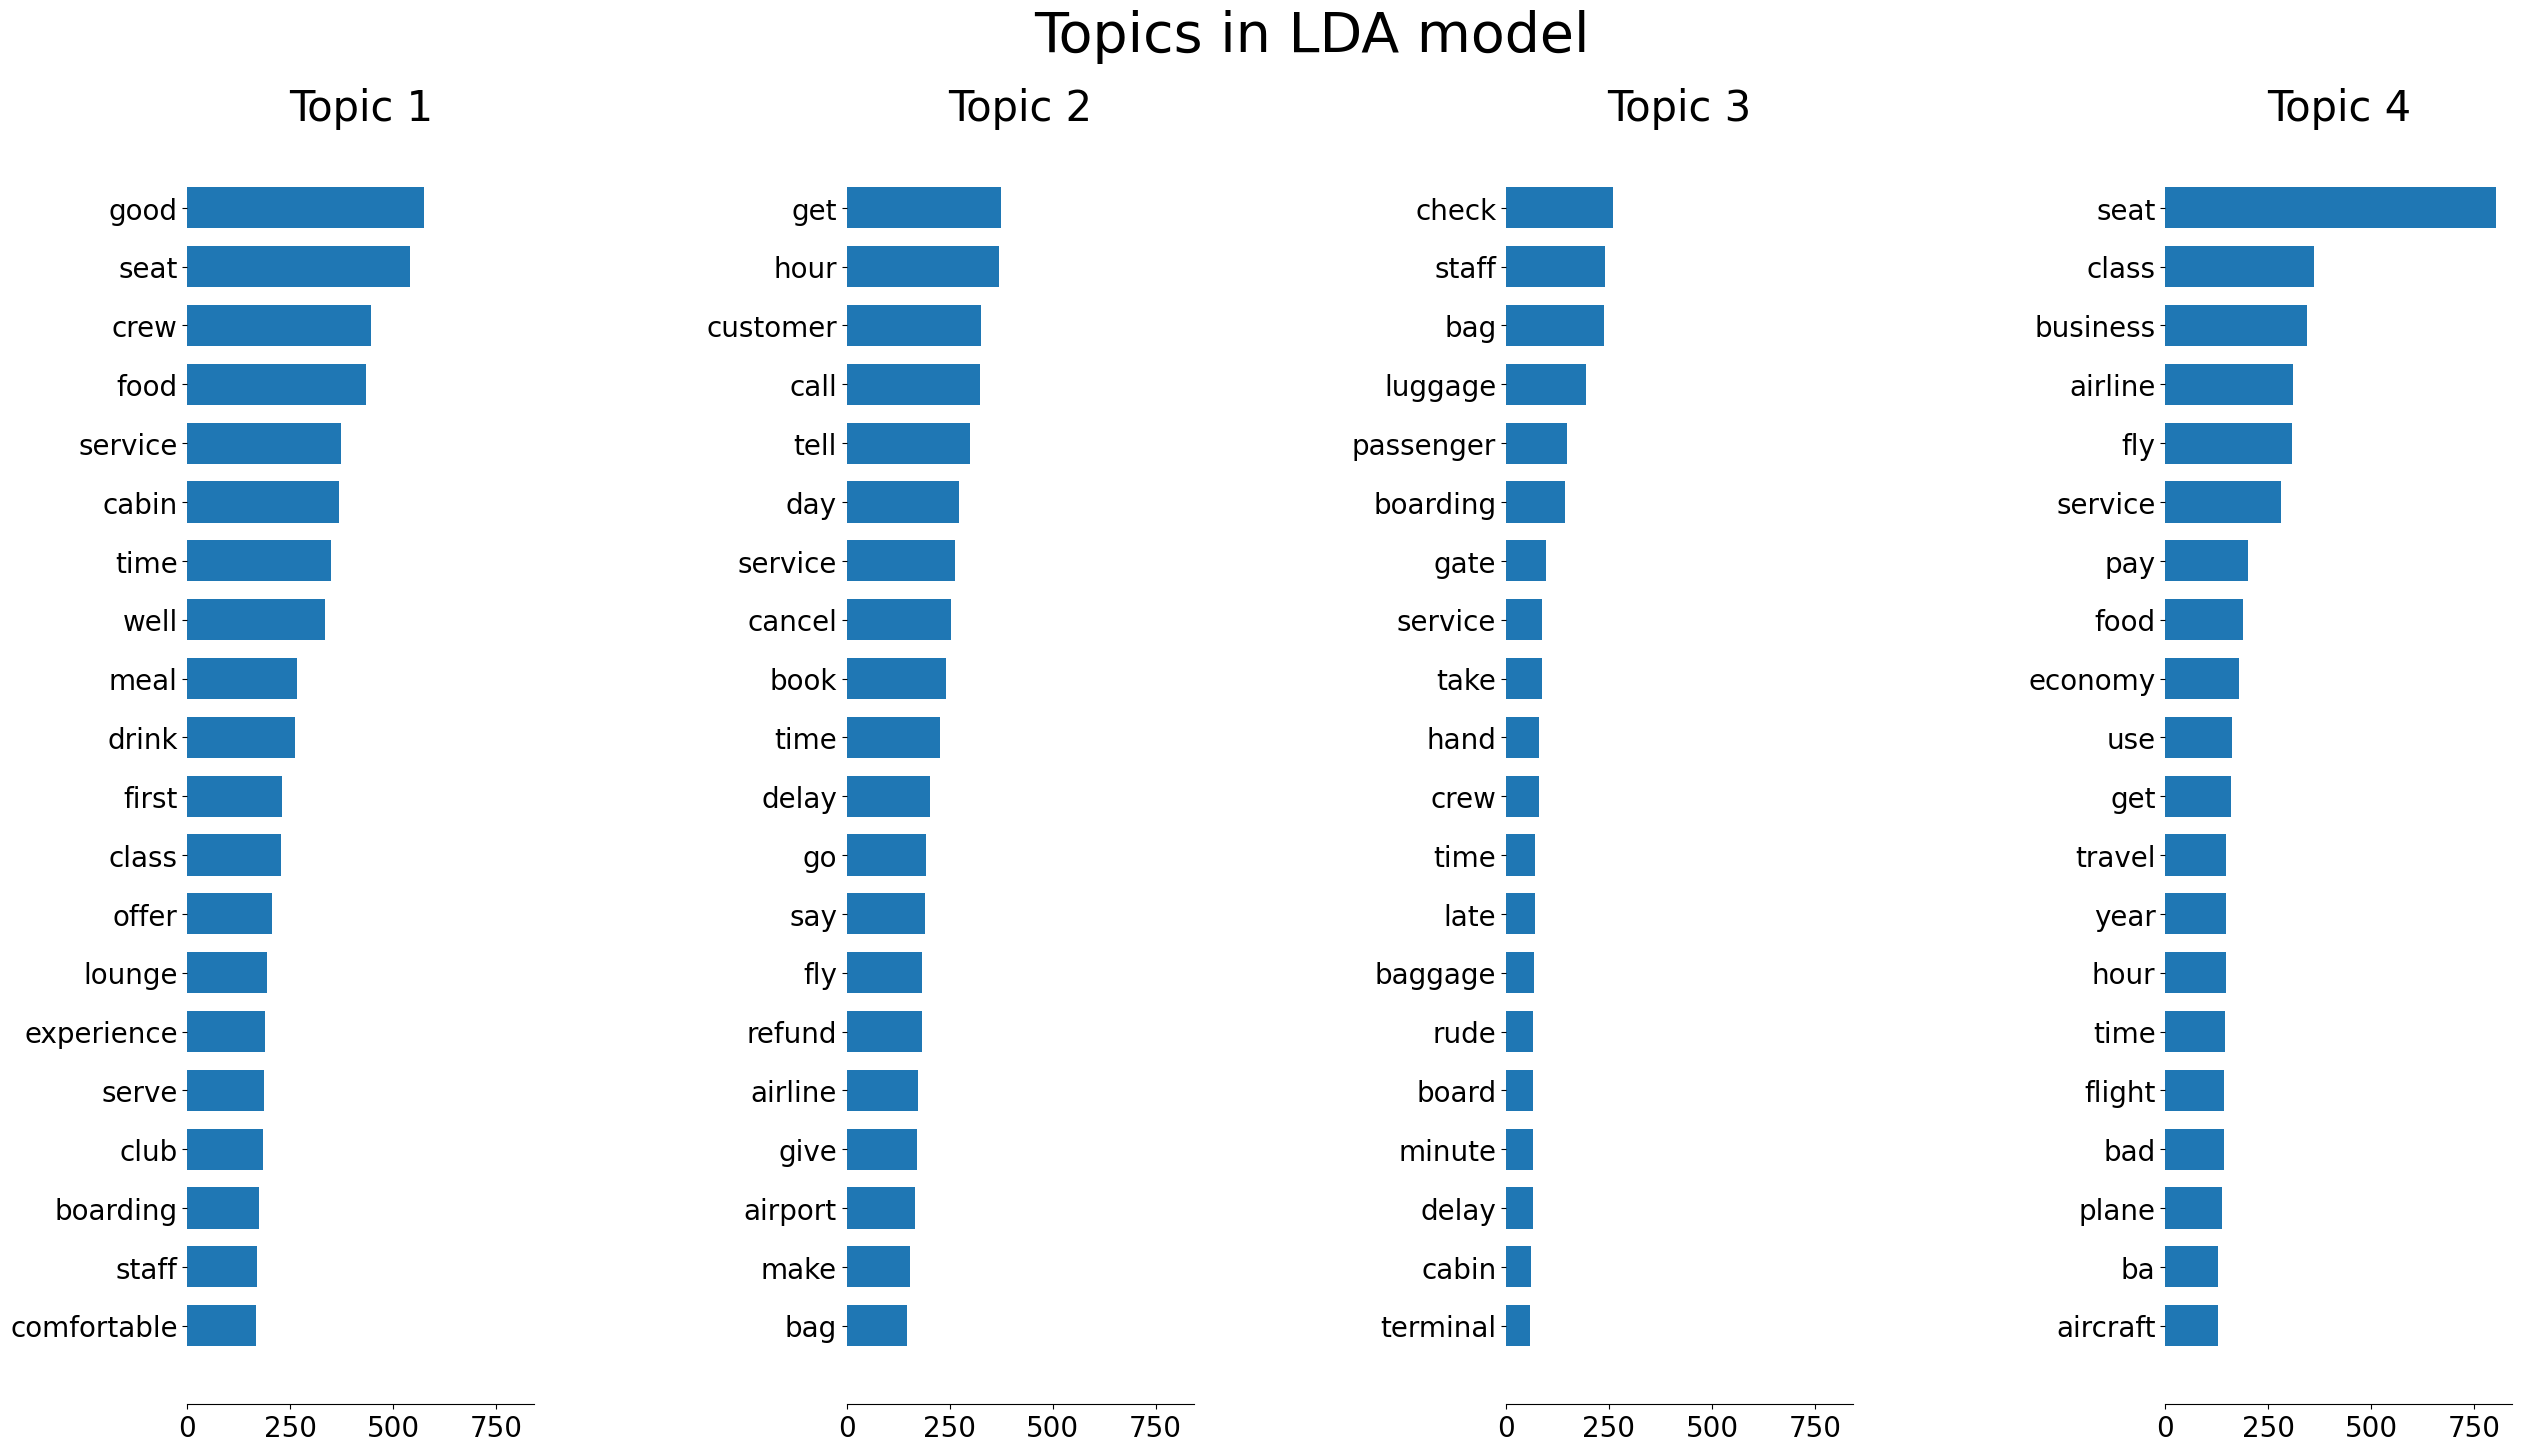

In [41]:
# Visualise the result into bar charts in topic

%matplotlib inline
import matplotlib.pyplot as plt

# helper function to plot topics
# see Grisel et al.
# https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 4, figsize=(30, 15), sharex=True) # Here you change the structure of the plot; first number is row and second number is column
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f'Topic {topic_idx +1}',
                     fontdict={'fontsize': 30})
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=20)
        for i in 'top right left'.split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

n_top_words = 20  #how many words to be visualised in each topic

# get the list of words (feature names)
vec_feature_names = vectorizer.get_feature_names_out() # Make sure you set the right vectorizer name

# print the top words per topic
plot_top_words(lda, vec_feature_names, n_top_words, 'Topics in LDA model') # Make sure you set the right lda model name

The above bar charts show the **top 20 words** for each topic, with bar length proportional to the word's weight in the topic distribution. Bar charts are preferable to word clouds when you need precise comparison between word weights within a topic.

**What to look for:**

- **Dominant words (long bars):** These define the core theme of the topic. The top 3–5 words usually capture the essence of the topic
- **Supporting words (shorter bars):** These provide context and nuance as they help distinguish similar topics (e.g. both a 'food' topic and a 'service' topic might contain `staff`, but the food topic has higher weights for `meal`, `drink`, `breakfast`)
- **Comparing bar lengths across topics:** If Topic 1's top word has a weight of 0.08 and Topic 3's top word only 0.03, Topic 1 has more concentrated, distinctive vocabulary — it's a 'tighter' topic

**Actionable business insights from BA topic model:**

Once topics are labelled, you can:
1. Calculate what proportion of reviews fall into each topic
2. Cross-tabulate topics against `user_ratings` to identify which topics correlate with low ratings (complaints)
3. Track topic prevalence over time using `published_dates` to detect emerging issues

---

### Exercise 4 — LDA Topic Modelling

1. **Change k:** Re-run the LDA model with `k=3` and then `k=6`. How do the topics change? Which value of `k` produces the most coherent, interpretable topics for airline reviews?

2. **Label the topics:** Based on the top words in each topic, write a short 2–3 word label for each topic (e.g. 'In-flight Service', 'Booking Issues'). Discuss with a classmate: do you agree on the labels?

3. **Inspect representative documents:** For each topic, find the review that is most strongly assigned to it. You can do this by transforming the DTM and finding the document with the highest proportion in topic k:
   ```python
   doc_topic_dist = lda.transform(vec)
   most_representative = doc_topic_dist[:, 0].argmax()  # change 0 to the topic index
   print(df['reviews'].iloc[most_representative])
   ```
   Do the representative reviews match your topic label?

4. **Custom stop words:** Add five more domain-specific stop words to the `stop_words.extend([...])` list based on what you observe in the LDA output (e.g. words that appear across all topics but don't differentiate them). Re-run the pipeline and LDA. Do the topics improve?


# 5. Topic Modelling with BERTopic

## Limitations of LDA

LDA is a powerful and interpretable model, but it has fundamental limitations:

- **Bag-of-words representation:** LDA treats each word as an independent unit, ignoring word order and context. The sentences *"The staff was not helpful"* and *"The staff was very helpful"* produce almost identical word vectors despite opposite meanings.
- **No semantic understanding:** LDA cannot recognise that `awful` and `terrible` are synonyms, or that `BA` refers to British Airways.
- **Fixed number of topics:** You must specify `k` in advance, which requires manual tuning.

## 5.1 BERTopic: Architecture Overview

**BERTopic** (Grootendorst, 2022) addresses these limitations by combining four modern components:

### Step 1: BERT Sentence Embeddings

Each review is encoded into a **dense vector** (embedding) using a pre-trained transformer model. We use `all-MiniLM-L6-v2` from the `sentence-transformers` library, which maps each document to a 384-dimensional vector that captures its *semantic meaning* — not just its word counts. Documents with similar meanings will have similar vectors, regardless of whether they use the same exact words.

### Step 2: Dimensionality Reduction with UMAP

384 dimensions are too many for clustering algorithms to work effectively (the *curse of dimensionality*). **UMAP** (Uniform Manifold Approximation and Projection) reduces the embeddings to a low-dimensional space (typically 2–10 dimensions) while preserving local and global structure. Think of it as a sophisticated version of PCA that works particularly well for non-linear manifolds.

### Step 3: Clustering with HDBSCAN

**HDBSCAN** (Hierarchical Density-Based Spatial Clustering of Applications with Noise) clusters the reduced embeddings. Unlike k-means or LDA, HDBSCAN:
- **Automatically determines the number of clusters** — you don't need to specify `k`
- **Identifies noise** — documents that don't belong to any cluster are labelled `-1` (the outlier topic)
- **Handles non-spherical clusters** — finds clusters of arbitrary shape

The `min_cluster_size` parameter controls granularity: higher values → fewer, broader topics; lower values → more, finer-grained topics.

### Step 4: Topic Representation with c-TF-IDF

Once clusters are found, BERTopic uses **class-based TF-IDF (c-TF-IDF)** to identify the most representative words for each topic. All documents in a cluster are concatenated and treated as one mega-document; then standard TF-IDF is applied to find words that are distinctive to that cluster versus all other clusters.

Additionally, the `KeyBERTInspired` representation model refines the top words by selecting those most semantically similar to the topic embedding using BERT itself.

## 5.2 LDA vs BERTopic Summary

| Feature | LDA | BERTopic |
|---------|-----|----------|
| Text representation | Bag-of-words counts | Dense semantic embeddings |
| Topic granularity | Fixed k (user-specified) | Automatic (HDBSCAN) |
| Semantic understanding | None | Full contextual meaning |
| Handles synonyms | No | Yes |
| Speed | Fast | Slower (embedding step) |
| Interpretability | High (probabilistic) | Moderate (black-box embeddings) |
| Outlier detection | No | Yes (topic -1) |


In [42]:
# You need to install the package before using it
!pip install bertopic

In [43]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic.representation import KeyBERTInspired
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Embedding model - choose a faster transformer model
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')  # This is faster than larger models

# Dimension reduction - keep the default
# umap_model = UMAP(n_neighbors=2, n_components=3, min_dist=0.05)

# Clustering - can also use to control number of topics
hdbscan_model = HDBSCAN(min_cluster_size=30, # A higher min_cluster_size will generate fewer topics and a lower min_cluster_size will generate more topics.
                        prediction_data=True) # This keeps additional data that allows assigning new documents to existing clusters later, which is useful if you want to classify new documents without retraining.


# Vectorizer - use a custom CountVectorizer with n-grams
stopwords = list(stopwords.words('english'))+ ['airline']
vectorizer = CountVectorizer(ngram_range=(1, 2),  # Include both unigrams and bigrams
                             stop_words=stopwords, # control the stop_words
                             min_df=5)  # Only include terms that appear in at least 5 documents

# c-TF-IDF - keep the default

# Fine-tune representation model
representation_model = KeyBERTInspired()


# Create a BERTopic model
topic_model = BERTopic(
    hdbscan_model=hdbscan_model,
    embedding_model=embedding_model,
    vectorizer_model=vectorizer,
    representation_model=representation_model,
    top_n_words=10,
    language='english',
    calculate_probabilities=True,
    verbose=True
)

# Fit the model to the cleaned reviews
topics, probs = topic_model.fit_transform(df['cleaned_review'])

# Check the documentation for more guidance on hyperparameter tuning: https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-02-22 18:19:32,023 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/41 [00:00<?, ?it/s]

2026-02-22 18:19:33,427 - BERTopic - Embedding - Completed ✓
2026-02-22 18:19:33,428 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-22 18:19:43,896 - BERTopic - Dimensionality - Completed ✓
2026-02-22 18:19:43,897 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-22 18:19:43,984 - BERTopic - Cluster - Completed ✓
2026-02-22 18:19:43,992 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-22 18:19:44,311 - BERTopic - Representation - Completed ✓


In [44]:
# Print the topics
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,769,-1_cabin crew_customer service_boarding_flight,"[cabin crew, customer service, boarding, fligh...",[much well experience time fly use bidv lounge...
1,0,224,0_cabin crew_boarding_flight_cabin,"[cabin crew, boarding, flight, cabin, passenge...",[overall comfortable airway flight take time r...
2,1,101,1_customer service_flight_airport_service,"[customer service, flight, airport, service, c...",[fly recently decide return back home travel d...
3,2,77,2_customer service_boarding_service_customer,"[customer service, boarding, service, customer...",[absolutely bad experience ever fly heathrow p...
4,3,52,3_flight_attendant_airway_plane,"[flight, attendant, airway, plane, fly, cabin,...",[nice aircraft food assistance information dep...
5,4,43,4_flight_fly_plane_airport,"[flight, fly, plane, airport, heathrow, airway...",[today friend fly apparently go well check ine...
6,5,34,5_boarding_cabin crew_cabin_plane,"[boarding, cabin crew, cabin, plane, check des...",[book begin go normal smooth check boarding ea...


The `get_topic_info()` table contains one row per discovered topic. The columns are:

| Column | Meaning |
|--------|----------|
| **Topic** | Topic ID. `-1` = outlier documents |
| **Count** | Number of reviews assigned to this topic |
| **Name** | Auto-generated label based on top words |
| **Representation** | List of the most representative keywords |

**Reading the table:**
- The topic with the highest count is the most prevalent theme in the reviews
- Topic `-1` contains documents that HDBSCAN could not confidently assign to any cluster — this is normal and expected
- The auto-generated names (e.g. `0_delay_cancel_seat`) give an immediate first impression of each topic's content


When using HDBSCAN, topic -1 contains all documents that couldn't be confidently assigned to any specific cluster. Having
reviews classified as outliers suggests a few possibilities:

- High diversity in your reviews: the reviews might cover many different topics with little overlap, making it difficult for the algorithm to find clear clusters.

- Noise in the data: If the reviews are short or contain unusual language patterns, they might be harder to cluster effectively.

In [45]:
topic_model.visualize_barchart(n_words=10, height=300)

The above bar charts show the **c-TF-IDF scores** of the top 10 words per topic. A higher score means the word is more distinctive to that topic compared to all other topics.

**Key observations:**

- **Topic coherence:** Because BERTopic uses semantic embeddings, the topics tend to be more semantically coherent than LDA topics — words that are semantically related (even if different surface forms) cluster together
- **Contrast with LDA:** Notice if BERTopic has found different topics than LDA. It may have discovered more specific sub-themes (e.g. separating 'seat comfort' from 'business class experience') or combined themes that LDA split unnecessarily
- **Bigrams:** Because the vectoriser uses `ngram_range=(1,2)`, you may see two-word phrases like `customer service` or `check in` as topic keywords — these are often more meaningful than individual words


In [46]:
topic_model.visualize_topics()

The `visualize_topics()` output is an interactive **intertopic distance map** — a 2D projection of the topic embeddings that gives an intuitive sense of topic relationships.

**Reading the map:**
- **Distance between topics:** Topics that are close together in the map are semantically similar (they share vocabulary and meaning). Topics far apart are distinct
- **Bubble size:** Proportional to the number of reviews in that topic (larger = more documents)
- **Cluster groups:** If two topics are visually near each other, consider merging them using `topic_model.merge_topics(docs, topics_to_merge=[[0,1]])`

**Business interpretation:** This map is useful for presenting topic structure to stakeholders. If 'baggage' and 'delays' topics cluster together, it suggests these issues co-occur and should be addressed together operationally.

---

### Exercise 5 — BERTopic

1. **Adjust min_cluster_size:** Change `min_cluster_size` from `30` to `15` and then `50`. How does the number of discovered topics change? Which setting gives the most meaningful topics for BA reviews?

2. **Add bigrams to custom stop words:** The vectoriser includes `'airline'` as a custom stop word. What other words appear in the topics that are domain-generic (not topic-specific)? Add them and re-run.

3. **Inspect topic -1:** Filter the dataframe to show only reviews assigned to topic -1:
   ```python
   outlier_reviews = df[df['topic'] == -1]['reviews']
   print(outlier_reviews.sample(5).to_string())
   ```
   What do these reviews have in common? Why might they be hard to cluster?

4. **Compare LDA and BERTopic:** Create a cross-tabulation of topics from the two models:
   ```python
   pd.crosstab(df['topic'], lda.transform(vec).argmax(axis=1))
   ```
   Do LDA topics and BERTopic topics align? Where do they agree and disagree?

5. **Different embedding model:** Replace `'all-MiniLM-L6-v2'` with `'paraphrase-mpnet-base-v2'` (a larger, more powerful model). Does the topic quality improve? What trade-off do you observe in processing time?


In [47]:
# Add the topics back to our dataframe
df['topic'] = topics

In [48]:
df.head()

,Unnamed: 0,title,reviews,published_dates,user_name,user_location,user_ratings,trip_details,would_recommed_to_others,cleaned_review,topic
0,0,“Worst service ever”,worst service ever lost baggage because of de...,23rd January 2024,Chirag Thummar,Germany,1,Type Of TravellerSolo Leisure\nSeat TypeEconom...,n,bad service ever lose baggage delay miss conne...,4
1,1,"""unprofessional attitude of the pilots""",ba jan did not appreciate the unprofessional ...,21st January 2024,D Carreno,United Kingdom,6,AircraftA350\nType Of TravellerBusiness\nSeat ...,n,appreciate unprofessional attitude pilot sched...,5
2,2,“Next time it will be Jet2”,not a great experience i could not check in o...,18th January 2024,Simon Channon,United Kingdom,3,AircraftA320\nType Of TravellerCouple Leisure\...,n,great experience check online separate part co...,5
3,3,“become the Ryanair of long-haul travel”,i was excited to fly ba as i would not travel...,18th January 2024,Melissa Harris,United Kingdom,2,Type Of TravellerFamily Leisure\nSeat TypeEcon...,n,excited fly ba travel long travel many occasio...,0
4,4,“They never help us”,i just want to warn everyone of the worst cus...,17th January 2024,Ivana Squassabia,Germany,1,Type Of TravellerFamily Leisure\nSeat TypeBusi...,n,want warn bad customer service experience ever...,-1


The `topic` column has been added to the DataFrame. Each review now has a topic ID from the BERTopic model. This enriched DataFrame enables further analysis:

- **Filter by topic:** `df[df['topic'] == 0]` shows all reviews in Topic 0
- **Cross-tabulate topic and rating:** `pd.crosstab(df['topic'], df['user_ratings'])` reveals which topics are associated with low vs high ratings
- **Time trends:** Merge with `published_dates` (after parsing to datetime) to track whether certain topics have increased over time

This structured output is the end product of the entire NLP pipeline — from raw, unstructured text to a labelled dataset that can be used for business intelligence and reporting.


# Check more NLP techniques

- [Use TextBlob and NLTK for sentiment analysis](https://colab.research.google.com/drive/1awgFrFAEi19XPWRsT_rebySoDewYF-j0?usp=sharing)
- [Connect with Google Natural Language API to do sentiment analysis](https://colab.research.google.com/drive/1Rqr3rrQUh4Rd4SQCmPWcWzqfjtIUKWwA?usp=sharing)